In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df=pd.read_csv('Car_Sales.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [8]:
df['fuel'].unique()


<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

In [9]:

fuel_id = {
    'Petrol': 0,
     'Diesel': 1,
     'CNG': 2,
     'LPG': 3,
     'Electric': 4
}
df['fuel_id']= df['fuel'].map(fuel_id)

In [10]:
seller_type_id ={
    'Individual': 0,
    'Dealer': 1,
    'Trustmark Dealer': 2
}
df['seller_type_id'] = df['seller_type'].map(seller_type_id)

In [11]:
df['transmission'].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [12]:
trasnformation_id={
    'Manual': 0, 
    'Automatic': 1
}
df['transmission_id']=df['transmission'].map(trasnformation_id)

In [13]:
df['owner'].unique()

<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str

In [14]:
owner_id={
    'First Owner':0,
    'Second Owner':1,
    'Third Owner':2,
    'Fourth & Above Owner':3,
    'Test Drive Car':4
}
df['owner_id']=df['owner'].map(owner_id)

In [15]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'fuel_id', 'seller_type_id', 'transmission_id',
       'owner_id'],
      dtype='str')

In [16]:
# Feature Selection
features = ['year', 'km_driven', 'fuel_id', 'seller_type_id', 'transmission_id', 'owner_id']
target = 'selling_price'

In [17]:
X = df[features]#multi dim list
Y = df[target]#multi  dim list'

In [18]:
#train test
X_train, X_test, Y_train, Y_test= train_test_split(
X, Y, test_size=0.2, random_state=42
)

In [19]:
#feature scaling
#standard scaler-> (Xi mean)/std
#only scale feature not target
scaler= StandardScaler()

In [32]:
#scale training data
X_train_scale=scaler.fit_transform(X_train)

#scale test data

X_test_scale= scaler.transform(X_test)

In [34]:
#use of linear regression model
model=LinearRegression()

#training model with feature scaling and target data
model.fit(X_train_scale, Y_train)

#testing data to make model learn its pattern so it can predict future upcoming values
Y_pred=model.predict(X_test_scale)

In [35]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,fuel_id,seller_type_id,transmission_id,owner_id
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,0,0,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,0,0,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,1,0,0,0
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,0,0,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,1,0,0,1
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,1,0,0,1
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,0,0,0,1
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,1,0,0,0


In [38]:
#model accuracy
#mean squared error(Ecludeian) -> actual from where the predction starts
rmse=np.sqrt(mean_squared_error(Y_test,Y_pred))

#r2 score=->accuracy number of how well model perform
r2=r2_score(Y_test,Y_pred)

print("room mean squared error", rmse)
print("R2 score (Accuracy)",r2)

room mean squared error 432407.7429128674
R2 score (Accuracy) 0.3873045160130879


In [41]:
#for straight line
x_min, x_max = [Y_test.min(),Y_test.max()] #straight line for horizontal
y_min, y_max = [Y_test.min(),Y_test.max()] #straight line for vertical


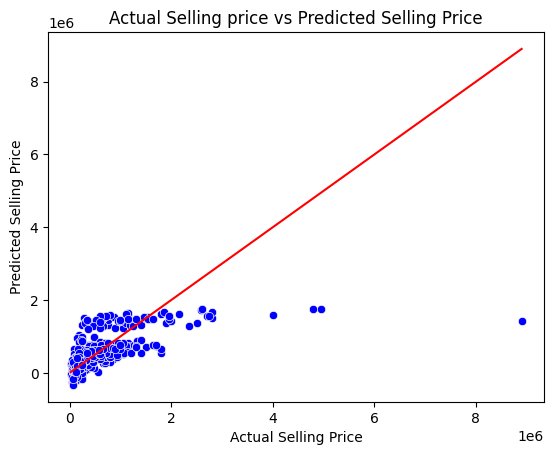

In [44]:
#visualization
#straight line
  
sns.scatterplot(x=Y_test.values.flatten(),y=Y_pred.flatten(),color='blue')
plt.plot([x_min,x_max],[y_min,y_max],color="red")
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual Selling price vs Predicted Selling Price')
plt.show()
  

In [46]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

In [48]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)
rf_pred = rf_model.predict(X_test)

In [49]:
rf_rsme = np.sqrt(mean_squared_error(Y_test,rf_pred))
rf_r2 = r2_score(Y_test,rf_pred)
print(f'Random Forest RMSE:{rf_rsme}')
print(f'random forest R2 score (accuracy):{rf_r2}')

Random Forest RMSE:391259.9346394743
random forest R2 score (accuracy):0.4983642135733023


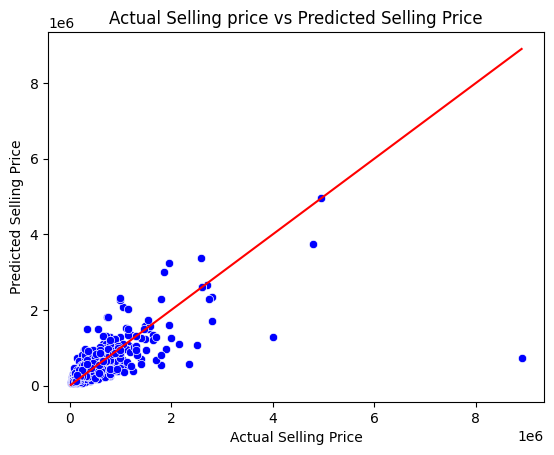

In [51]:
sns.scatterplot(x=Y_test.values.flatten(),y=rf_pred.flatten(),color='blue')
plt.plot([x_min,x_max],[y_min,y_max],color="red")
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual Selling price vs Predicted Selling Price')
plt.show()